LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")

processed = BASE_DIR / "data" / "processed"
raw = BASE_DIR / "data" / "raw"
charts = BASE_DIR / "reports" / "charts"

daily_returns = pd.read_csv(processed / "daily_returns.csv")
fund_scorecard = pd.read_csv(processed / "fund_scorecard.csv")
investors = pd.read_csv(processed / "investor_transactions_clean.csv")
holdings = pd.read_csv(raw / "09_portfolio_holdings.csv")
fund_master = pd.read_csv(raw / "01_fund_master.csv")

print("Loaded successfully")

Loaded successfully


# VaR & CVaR

In [2]:
var_results = []

for fund in daily_returns['amfi_code'].unique():

    temp = daily_returns[
        daily_returns['amfi_code'] == fund
    ]

    returns = temp['daily_return'].dropna()

    if len(returns) == 0:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[
        returns <= var95
    ].mean()

    var_results.append([
        fund,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.to_csv(
    processed / "var_cvar_report.csv",
    index=False
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


# Rolling 90-Day Sharpe

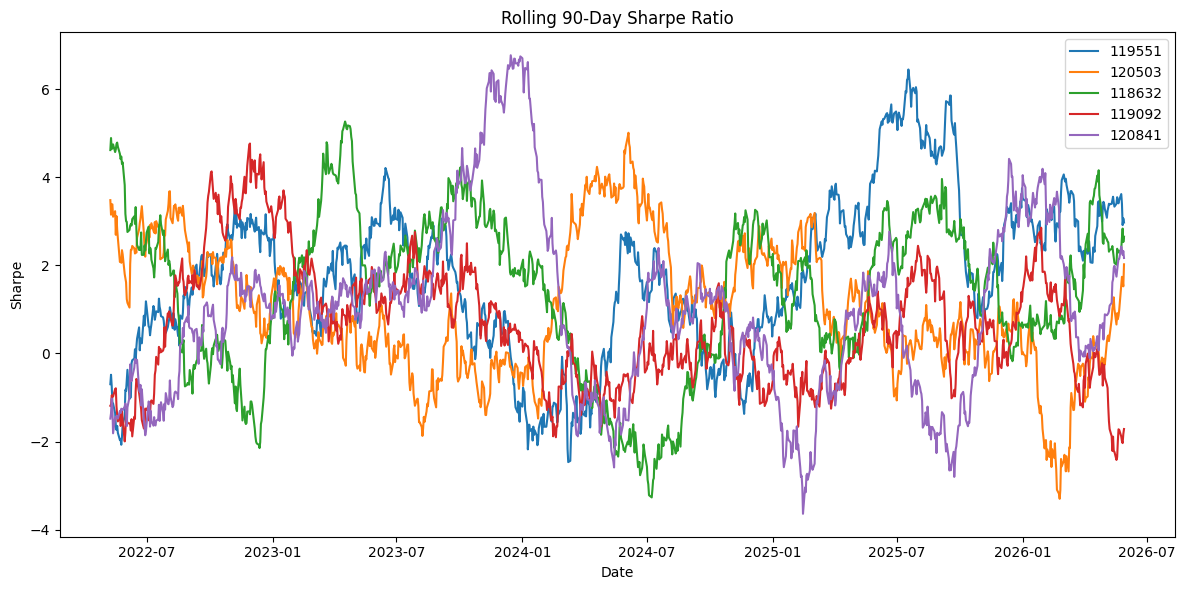

In [3]:
key_funds = [
    119551,
    120503,
    118632,
    119092,
    120841
]

plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = daily_returns[
        daily_returns['amfi_code'] == fund
    ].copy()

    temp['date'] = pd.to_datetime(
        temp['date']
    )

    temp = temp.sort_values('date')

    rolling_sharpe = (
        temp['daily_return']
        .rolling(90)
        .mean()
        /
        temp['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")

plt.tight_layout()

plt.savefig(
    charts / "rolling_sharpe_chart.png"
)

plt.show()

# Investor Cohort Analysis

In [6]:
# Find the amount column automatically
amount_col = [c for c in investors.columns if 'amount' in c.lower()][0]

print("Using column:", amount_col)

# Create cohort analysis
investors['transaction_date'] = pd.to_datetime(investors['transaction_date'])

investors['cohort_year'] = (
    investors.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

cohort = (
    investors.groupby('cohort_year')
    .agg(
        avg_sip=(amount_col, 'mean'),
        total_invested=(amount_col, 'sum')
    )
    .reset_index()
)

cohort

Using column: amount_inr


,cohort_year,avg_sip,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [5]:
print(investors.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [15]:
# top fund per cohort
top_fund = (
    investors
    .groupby(
        ['cohort_year','amfi_code']
    )['amount_inr']
    .sum()
    .reset_index()
)

top_fund = (
    top_fund
    .sort_values(
        'amount_inr',
        ascending=False
    )
    .groupby('cohort_year')
    .first()
)

top_fund

,amfi_code,amount_inr
cohort_year,,
2024,102885,100126141
2025,119599,1478507


# SIP Continuity Analysis

In [16]:
sip = investors[
    investors['transaction_type']
    == 'SIP'
].copy()

sip = sip.sort_values(
    ['investor_id',
     'transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

continuity = (
    sip.groupby('investor_id')
    .agg(
        sip_count=('gap_days','count'),
        avg_gap=('gap_days','mean')
    )
)

continuity = continuity[
    continuity['sip_count'] >= 6
]

continuity['status'] = np.where(
    continuity['avg_gap'] > 35,
    'At Risk',
    'Healthy'
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000011,6,40.166667,At Risk
INV000012,7,57.000000,At Risk
INV000013,6,55.333333,At Risk
INV000014,6,75.333333,At Risk
INV000023,7,58.571429,At Risk


In [17]:
continuity['status'].value_counts()

status
At Risk    813
Healthy     21
Name: count, dtype: int64

In [19]:
# HHI Concentration
holdings['weight_pct'] = (
    holdings['weight_pct']
    .astype(float)
)

hhi = (
    holdings
    .groupby('amfi_code')
    ['weight_pct']
    .apply(
        lambda x:
        np.sum(
            (x/100)**2
        )
    )
)

hhi = hhi.reset_index()

hhi.columns = [
    'amfi_code',
    'HHI'
]

hhi.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


Insight 1:
----------
Funds with the highest VaR exhibit larger downside risk and may not be suitable for conservative investors.

Insight 2:
----------
CVaR values are consistently worse than VaR, indicating heavier losses during extreme market declines.

Insight 3:
----------
The newest investor cohorts contributed the highest aggregate investment amounts.

Insight 4:
----------
Most SIP investors maintain regular contributions, but at-risk investors show average gaps exceeding 35 days.

Insight 5:
----------
Funds with high HHI values are concentrated in fewer sectors and therefore carry higher concentration risk.